# 12 — Animating data on the globe

The globe is a static frame, but a **stack of rasters** can be animated over it. Digital-Earth ships two globe-animation methods on `Map`:

- **`Map.animate(stack, ...)`** — step a stack of grids (here the 12 monthly WorldClim temperature fields) frame by frame.
- **`Map.rotate(dataset, ...)`** — keep one field and sweep the orthographic centre longitude to spin the Earth.

Both return a `matplotlib.animation.FuncAnimation`. Internally each frame is a full `Map(globe=True)` draw — **pyramids** reprojects, **cleopatra** renders, and the projection frame is applied — so frames get coastlines, graticule, and limb-clipping for free.

> The GIFs are written to a temp file and embedded into the notebook output, so nothing extra is committed. WorldClim downloads on first run (cached, git-ignored).

## Setup & data

Download the monthly temperature stack and the global elevation grid (cached).

In [1]:
%matplotlib inline
import io, os, zipfile, urllib.request as u
from pathlib import Path
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from digitalearth.scene import Map, projections
from cleopatra.glyphs.base.animation import embed_gif   # cleopatra 0.13.0: FuncAnimation -> inline GIF

CACHE = Path('../../examples/data/global'); CACHE.mkdir(parents=True, exist_ok=True)
BASE = 'https://geodata.ucdavis.edu/climate/worldclim/2_1/base/'

def fetch(product):
    """Download+unzip a WorldClim 10m product, returning the sorted cached GeoTIFF paths."""
    tifs = sorted(CACHE.glob(f'{product}*.tif'))
    if not tifs:
        blob = u.urlopen(u.Request(BASE + f'{product}.zip', headers={'User-Agent': 'Mozilla/5.0'}),
                         timeout=300).read()
        with zipfile.ZipFile(io.BytesIO(blob)) as z:
            for n in z.namelist():
                if n.endswith('.tif'):
                    (CACHE / os.path.basename(n)).write_bytes(z.read(n))
        tifs = sorted(CACHE.glob(f'{product}*.tif'))
    return tifs

MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
tavg = [Dataset.read_file(str(p)) for p in fetch('wc2.1_10m_tavg')]   # 12-grid stack
elevation = Dataset.read_file(str(fetch('wc2.1_10m_elev')[0]))
print('stack:', len(tavg), 'monthly grids; elevation:', elevation.rows, 'x', elevation.columns)

stack: 12 monthly grids; elevation: 1080 x 2160


## Embedding the animation — `cleopatra.glyphs.base.animation`

`Map.animate` / `Map.rotate` return a `matplotlib.animation.FuncAnimation`. cleopatra 0.13.0 turns one into an inline GIF with **`embed_gif(anim, fps)`** (also `to_gif(anim, fps)` for raw bytes and `save_animation(anim, path, fps)` to write a file — gif/mp4/mov/avi). We `embed_gif` each animation below, then `plt.close(...)` the figure so the final frame is not also drawn statically under `%matplotlib inline`.

## 1. Seasonal time animation — `Map.animate`

Pass the 12-month stack to `Map.animate`. No `vmin`/`vmax` is needed — every frame shares **one colour scale**, computed once from the whole stack, so the colours and the colorbar stay comparable across frames. `ocean=True` fills the disc and `coastlines=True` overlays the coast each frame. Watch the warm band swing north in July and south in January.

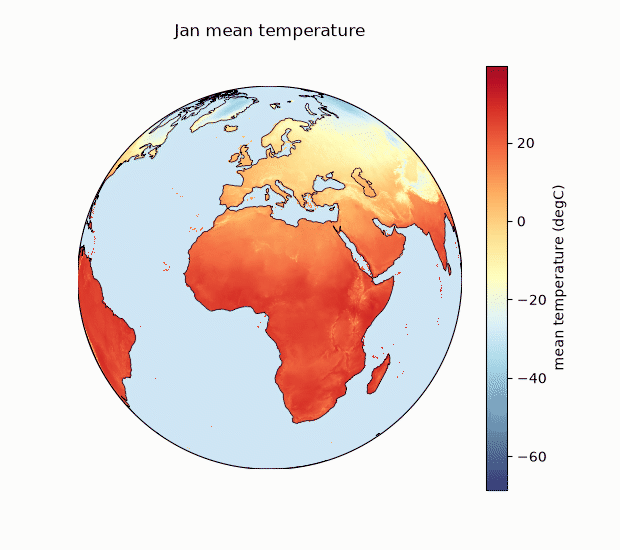

In [2]:
FPS = 3
m = Map(crs=projections.orthographic(lon=10, lat=15), globe=True, figsize=(6.2, 5.5))
anim = m.animate(
    tavg, kind='imshow', fps=FPS,
    titles=[f'{mo} mean temperature' for mo in MONTHS],
    ocean=True, coastlines=True, cmap='RdYlBu_r',
    colorbar=True, cbar_label='mean temperature (degC)',
)
gif = embed_gif(anim, FPS)
plt.close(m.fig)   # avoid a duplicate static frame under %matplotlib inline
gif

## 2. Rotating globe — `Map.rotate`

`Map.rotate` sweeps the orthographic centre longitude through 360 degrees over a single field. Ocean cells are nodata, so the `ocean()` disc shows through the sea.

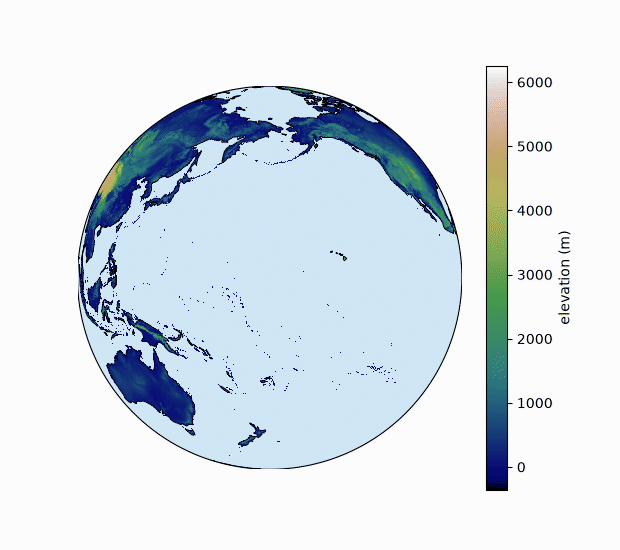

In [3]:
m = Map(crs=projections.orthographic(lon=0, lat=15), globe=True, figsize=(6.2, 5.5))
anim = m.rotate(
    elevation, lat=15, n_frames=24, fps=8,
    ocean=True, coastlines=True, cmap='gist_earth',
    colorbar=True, cbar_label='elevation (m)',
)
gif = embed_gif(anim, 8)
plt.close(m.fig)
gif

## Notes

- **Stacks.** Here the stack is a list of `Dataset`s; pyramids' `DatasetCollection` (a datacube) is the natural container for a real time stack and indexes the same way.
- **Cost.** Each frame is a full reproject + frame, so animations are heavier than a single map — keep the frame count and figure size modest.
- **Colorbar.** `colorbar=True` adds a single static colorbar (drawn once, not per frame); pass `cbar_label` for its label. If `vmin`/`vmax` are omitted they are computed from the stack so the colours and the bar stay stable across frames.